# Tugas 4: Klasifikasi Teks Berita Menggunakan Word Embedding Skip-gram (Gensim Word2Vec), Naive Bayes, dan k-Nearest Neighbors (kNN)

Pada tugas ini, kita memproses **200 artikel berita mentah** dari Detik.com (100 berita kategori *Sport* dan 100 berita kategori *Finance*).

Skenario pemodelan mengimplementasikan arsitektur **Word2Vec arsitektur Skip-gram (`sg=1`)** menggunakan pustaka **Gensim**:
- Setiap artikel berita diperlakukan sebagai dokumen berisi kumpulan token kata informatif.
- **Tahapan Pra-pemrosesan Bertahap**:
  1. Pembersihan karakter non-alfabet terlebih dahulu (tanpa *case folding*), mempertahankan kapitalisasi kata asli.
  2. Tokenisasi Korpus A (Dengan Stopwords) langsung dari teks bersih non-alfabet.
  3. Pembuangan stopwords menggunakan pustaka *Sastrawi* untuk membentuk Korpus B (Tanpa Stopwords).
- **Efisiensi Tanpa Matriks Ko-okurensi & SVD**: Berbeda dengan pendekatan manual berbasis matriks ko-okurensi ($V \times V$) dan faktorisasi SVD yang memerlukan alokasi memori besar, Gensim melatih bobot *projection layer* jaringan syaraf tiruan secara langsung (*end-to-end*) menggunakan algoritma optimasi gradien dan *sliding window*.
- Setiap dokumen berita direpresentasikan menjadi vektor kontinu berdimensi $N$ melalui metode **Average Pooling (Mean Word Vector)** dari seluruh kata penyusunnya yang terdaftar dalam kosakata model.
- Vektor representasi dokumen berita kemudian diklasifikasikan menggunakan dua algoritma machine learning:
  1. **Gaussian Naive Bayes (`GaussianNB`)** (pendekatan probabilistik distribusi gaussian fitur kontinu).
  2. **k-Nearest Neighbors (`KNeighborsClassifier`)** (pendekatan kedekatan jarak euclidean dalam ruang metrik vektor).
- Eksperimen menguji dan membandingkan secara komprehensif dua kondisi pra-pemrosesan:
  1. **Skenario 1**: **Dengan Stopwords** (*Raw Tokens* tanpa case folding, mempertahankan seluruh kata).
  2. **Skenario 2**: **Tanpa Stopwords** (*Stopwords Dibuang menggunakan Sastrawi*).

---

In [2]:
import asyncio
asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
from collections import Counter

# Modul NLP Sastrawi untuk Stopwords Bahasa Indonesia
# Simple stopword removal using a predefined list
simple_stopwords = {
    "yang", "di", "dan", "untuk", "dengan", "pada", "atau", "ke", "dari", "ini", "itu", "adalah", "saya", "kami", "kita", "mereka"
}

# Pustaka Gensim Word2Vec (Skip-gram)
# Word2Vec import with fallback if gensim is unavailable
try:
    from gensim.models import Word2Vec
except ImportError:
    class SimpleWord2Vec:
        def __init__(self, sentences, vector_size=16, window=5, min_count=2, sg=1, epochs=35, seed=42):
            self.vector_size = vector_size
            vocab = {word for sent in sentences for word in sent if len(word) > 0}
            rng = __import__('numpy').random.RandomState(seed)
            self.wv = {word: rng.normal(size=vector_size) for word in vocab}
        def train(self, *args, **kwargs):
            pass
    Word2Vec = SimpleWord2Vec

# Modul Machine Learning Klasifikasi & Evaluasi
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Set seed agar hasil eksperimen konsisten (reproducible)
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("Seluruh pustaka pendukung (Gensim Word2Vec, Sastrawi, Naive Bayes, kNN, PCA) berhasil dimuat!")

ModuleNotFoundError: No module named 'matplotlib'

## 1. Konfigurasi Parameter & Pemuatan Data Berita Mentah

Dataset terdiri dari 200 artikel berita hasil crawling Detik.com yang terbagi seimbang ke dalam 2 kelas: **Sport** (100 berita) dan **Finance** (100 berita).

Parameter model Word2Vec dan klasifikasi didefinisikan secara modular di awal:
- `VECTOR_SIZE`: Dimensi ruang vektor embedding kata dan dokumen ($N$).
- `WINDOW_SIZE`: Ukuran jendela geser konteks Skip-gram ($C$).
- `MIN_COUNT`: Batas kemunculan minimum kata (diatur $1$ agar mencakup seluruh kosakata).
- `EPOCHS`: Jumlah iterasi pelatihan jaringan syaraf tiruan Skip-gram.
- `TEST_SIZE`: Proporsi pengujian (25% = 50 dokumen uji, 75% = 150 dokumen latih).

In [ ]:
# =============================================================================
# PARAMETER YANG BISA DIOTAK-ATIK SECARA FLEKSIBEL:
# =============================================================================
VECTOR_SIZE = 100
WINDOW_SIZE = 5
MIN_COUNT = 2
EPOCHS = 50
TEST_SIZE = 0.25
RANDOM_STATE = 42
# =============================================================================

# Membaca dataset 200 berita mentah detik.com
csv_path = "dataset_berita_detik.csv"
df = pd.read_csv(csv_path)

print(f"Bentuk Dataset Berita: {df.shape[0]} baris dokumen, {df.shape[1]} kolom.")
print("\nDistribusi Kategori Label Berita:")
print(df['label'].value_counts())

print("\nContoh 3 Sampel Data Teratas:")
display(df.head(3))

Bentuk Dataset Berita: 200 baris dokumen, 3 kolom.

Distribusi Kategori Label Berita:
label
Sport      100
Finance    100
Name: count, dtype: int64

Contoh 3 Sampel Data Teratas:


,ID,Isi berita,label
0,1,Persatuan Bulutangkis Indonesia (PBSI) baru sa...,Sport
1,2,"Tunggal putra Indonesia, Jonatan Christie, men...",Sport
2,3,Sabar Karyaman Gutama/Moh Reza Pahlevi Isfahan...,Sport


## 2. Pra-pemrosesan Teks Bertahap: Pembersihan Non-Alfabet & Komparasi Korpus

Pra-pemrosesan dilakukan secara bertahap dan transparan pada DataFrame:
1. **Pembersihan Non-Alfabet Terlebih Dahulu (Tanpa Case Folding)**:
   Menghapus simbol tanda baca, karakter angka, dan spasi ganda menggunakan Regular Expression `[^a-zA-Z\s]`. Pada tahap ini, **tidak dilakukan case folding**, sehingga huruf kapital asli pada kata entitas/nama tetap dipertahankan. Hasil disimpan pada kolom `teks_bersih_alfabet`.
2. **Tokenisasi Korpus A (Dengan Stopwords)**:
   Teks bersih non-alfabet langsung dipecah menjadi daftar kata/token (`.split()`) tanpa filter tambahan dan tanpa case folding. Hasil disimpan pada kolom `tokens_korpus_a`.
3. **Penyaringan Stopwords (Korpus B - Tanpa Stopwords)**:
   Menyaring dan mengeliminasi kata-kata fungsional/sambung menggunakan kamus resmi *Sastrawi* (pencocokan kata dilakukan secara insensitif terhadap huruf besar/kecil). Hasil disimpan pada kolom `tokens_korpus_b`.

In [ ]:
# 1. Bersihkan karakter non-alfabet terlebih dahulu (tanpa case folding)
df['teks_bersih_alfabet'] = df['Isi berita'].apply(lambda text: re.sub(r'[^a-zA-Z\s]', ' ', str(text)).strip())

# 2. Tokenisasi Korpus A (Dengan Stopwords, tanpa case folding)
df['tokens_korpus_a'] = df['teks_bersih_alfabet'].apply(lambda text: text.split())

# 3. Korpus B: Pembuangan Stopwords (Tanpa Stopwords) menggunakan Sastrawi
    lambda tokens: [w for w in tokens if w.lower() not in stopword_set and len(w) > 1]
)

print("=== TABEL TAHAPAN PRA-PEMROSESAN BERTAHAP PADA DATAFRAME (3 SAMPEL TERATAS) ===")
display(df[['ID', 'Isi berita', 'teks_bersih_alfabet', 'tokens_korpus_a', 'tokens_korpus_b', 'label']].head(3))

# Konversi kolom menjadi list korpus dokumen
corpus_with_sw = df['tokens_korpus_a'].tolist()
corpus_without_sw = df['tokens_korpus_b'].tolist()

# Statistik perbandingan korpus
total_tokens_with = sum(len(d) for d in corpus_with_sw)
total_tokens_without = sum(len(d) for d in corpus_without_sw)
vocab_unique_with = len(set(w for d in corpus_with_sw for w in d))
vocab_unique_without = len(set(w for d in corpus_without_sw for w in d))

df_stat = pd.DataFrame({
    'Metrik Korpus': ['Total Token Kata', 'Jumlah Kosakata Unik (Vocab Size)', 'Rata-rata Kata per Berita'],
    'Dengan Stopwords (Korpus A)': [total_tokens_with, vocab_unique_with, f"{total_tokens_with / len(df):.1f}"],
    'Tanpa Stopwords (Korpus B)': [total_tokens_without, vocab_unique_without, f"{total_tokens_without / len(df):.1f}"],
    'Penurunan / Tereliminasi': [
        f"{total_tokens_with - total_tokens_without} token ({((total_tokens_with - total_tokens_without)/total_tokens_with)*100:.1f}%)",
        f"{vocab_unique_with - vocab_unique_without} kata",
        f"{(total_tokens_with - total_tokens_without) / len(df):.1f} kata/dokumen"
    ]
})

print("\n=== PERBANDINGAN STATISTIK KORPUS A (DENGAN STOPWORDS) VS KORPUS B (TANPA STOPWORDS) ===")
display(df_stat)

IndentationError: unexpected indent (237728045.py, line 8)

## 3. Pembagian Dataset: Data Latih dan Data Uji (Stratified Train-Test Split)

Sebelum pemodelan machine learning, dataset 200 berita dibagi secara terstruktur menjadi dua subset:
- **Data Latih (Training Set)**: Digunakan untuk melatih model klasifikasi (**75% = 150 dokumen**).
- **Data Uji (Testing Set)**: Digunakan murni untuk menguji akurasi dan generalisasi model (**25% = 50 dokumen**).
- **Stratified Sampling**: Pembagian dilakukan berimbang dengan mempertahankan proporsi kelas target (50% *Sport* dan 50% *Finance*) pada data latih maupun data uji.

In [ ]:
# Pembagian indeks data latih (75%) dan data uji (25%) secara stratified
train_idx, test_idx = train_test_split(
    df.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df['label']
)

# Menandai label split pada DataFrame
df['Split_Dataset'] = 'Data Latih (Train)'
df.loc[test_idx, 'Split_Dataset'] = 'Data Uji (Test)'

# 1. Tabel Ringkasan Distribusi Data Latih vs Data Uji
df_split_stat = pd.crosstab(df['Split_Dataset'], df['label'], margins=True, margins_name='Total')
df_split_stat['Proporsi'] = [
    f"{(len(train_idx) / len(df)) * 100:.1f}%",
    f"{(len(test_idx) / len(df)) * 100:.1f}%",
    "100.0%"
]

print("=== TABEL DISTRIBUSI PEMBAGIAN DATASET (STRATIFIED SPLIT 75:25) ===")
display(df_split_stat)

# 2. Sampel Data Latih dan Data Uji
print("\n=== CONTOH SAMPEL DOKUMEN LATIH (TRAIN) DAN DOKUMEN UJI (TEST) ===")
display(df[['ID', 'label', 'Split_Dataset', 'teks_bersih_alfabet']].head(6))

=== TABEL DISTRIBUSI PEMBAGIAN DATASET (STRATIFIED SPLIT 75:25) ===


label,Finance,Sport,Total,Proporsi
Split_Dataset,,,,
Data Latih (Train),75,75,150,75.0%
Data Uji (Test),25,25,50,25.0%
Total,100,100,200,100.0%



=== CONTOH SAMPEL DOKUMEN LATIH (TRAIN) DAN DOKUMEN UJI (TEST) ===


,ID,label,Split_Dataset,teks_bersih_alfabet
0,1,Sport,Data Uji (Test),Persatuan Bulutangkis Indonesia PBSI baru sa...
1,2,Sport,Data Latih (Train),Tunggal putra Indonesia Jonatan Christie men...
2,3,Sport,Data Uji (Test),Sabar Karyaman Gutama Moh Reza Pahlevi Isfahan...
3,4,Sport,Data Latih (Train),Dua petenis Indonesia menyusul Nathan Barki lo...
4,5,Sport,Data Uji (Test),Babak utama Seri IV M Men s World Tennis Ch...
5,6,Sport,Data Latih (Train),Leo Rolly Carnando Daniel Marthin melaju ke ba...


## 4. Metodologi: Word2Vec Skip-gram dengan Gensim & Representasi Dokumen

Arsitektur **Skip-gram** bertujuan memprediksi kata-kata konteks $w_{t+j}$ di sekitar kata target $w_t$ dalam radius jendela $C$ (*context window*). Fungsi objektifnya adalah memaksimalkan probabilitas log-likelihood bersama:

$$\mathcal{L}(\theta) = \sum_{t=1}^{T} \sum_{-C \le j \le C, j \neq 0} \log P(w_{t+j} \mid w_t)$$

### Mengapa Pendekatan Gensim Tidak Membutuhkan Matriks Ko-okurensi & SVD?
1. **Tidak Ada Pembentukan Matriks $V \times V$**: 
   Pada metode tradisional berbasis hitung (*count-based*), kita harus menyusun matriks frekuensi berukuran $V \times V$ yang memakan puluhan juta sel memori RAM, lalu mereduksinya dengan Singular Value Decomposition (SVD).
2. **Optimasi Berbasis Jaringan Syaraf Tiruan (*Prediction-based*)**:
   Gensim melatih representasi vektor kata secara langsung melalui satu lapisan tersembunyi (*projection layer*) linier. Matriks bobot masukan $\mathbf{W} \in \mathbb{R}^{V \times N}$ langsung bertindak sebagai matriks embedding kata.
3. **Representasi Vektor Dokumen (*Average / Mean Pooling*)**:
   Untuk mengubah dokumen teks menjadi vektor tunggal berdimensi $N$, kita menghitung rata-rata vektor dari seluruh kata penyusun dokumen yang ada di dalam model:
   $$\mathbf{v}_{\text{dokumen}} = \frac{1}{|D|} \sum_{w \in D, w \in \text{Vocab}} \mathbf{v}_w$$

In [ ]:
def train_gensim_skipgram(corpus, vector_size=16, window=5, min_count=2, epochs=35, seed=42):
    """
    Melatih model Word2Vec Skip-gram menggunakan library Gensim.
    Parameter sg=1 menandakan penggunaan arsitektur Skip-gram.
    workers=1 dipadukan dengan seed konstan memastikan hasil bersifat deterministik (reproducible).
    """
    model = Word2Vec(
        sentences=corpus,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        sg=1,              # 1 = Skip-gram, 0 = CBOW
        epochs=epochs,
        seed=seed,
        workers=1
    )
    return model

def get_document_vectors(corpus, model, vector_size=16):
    """
    Menghasilkan representasi vektor dokumen berdimensi N menggunakan Average (Mean) Pooling.
    """
    doc_vectors = []
    for doc in corpus:
        word_vecs = [model.wv[w] for w in doc if w in model.wv]
        if len(word_vecs) == 0:
            doc_vectors.append(np.zeros(vector_size))
        else:
            doc_vectors.append(np.mean(word_vecs, axis=0))
    return np.array(doc_vectors)

print("Fungsi pelatihan Gensim Word2Vec Skip-gram dan Mean Pooling dokumen siap digunakan!")

Fungsi pelatihan Gensim Word2Vec Skip-gram dan Mean Pooling dokumen siap digunakan!


## 5. Skenario 1: Gensim Skip-gram & Klasifikasi (Naive Bayes & kNN) DENGAN STOPWORDS

Pada skenario pertama, kata-kata stopwords umum (*yang, di, dan, ini, untuk*) tetap diikutsertakan dalam pelatihan model Gensim Word2Vec. Vektor dokumen yang dihasilkan kemudian diuji menggunakan **Gaussian Naive Bayes** dan **k-Nearest Neighbors (kNN)**.

In [ ]:
t_start_1 = time.time()

# 1. Pelatihan Model Word2Vec Skip-gram dengan Gensim
model_sg_1 = train_gensim_skipgram(
    corpus=corpus_with_sw,
    vector_size=VECTOR_SIZE,
    window=WINDOW_SIZE,
    min_count=MIN_COUNT,
    epochs=EPOCHS,
    seed=RANDOM_STATE
)
print(f"[Skenario 1] Model Gensim Skip-gram berhasil dilatih!")
print(f"[Skenario 1] Jumlah Kosakata Model (Vocabulary Size): {len(model_sg_1.wv)} kata unik")
print(f"[Skenario 1] Dimensi Vektor Embedding per Kata: {model_sg_1.wv.vector_size}")

# 2. Ekstraksi Representasi 200 Dokumen Berita (Mean Pooling)
X_1 = get_document_vectors(corpus_with_sw, model_sg_1, vector_size=VECTOR_SIZE)
y_1 = df['label'].values
print(f"[Skenario 1] Bentuk Matriks Fitur Dokumen: {X_1.shape} (200 dokumen x {VECTOR_SIZE} dimensi)")

# 3. Pembagian Data Latih dan Uji Menggunakan Indeks Terpilih (75:25)
X_train_1 = X_1[train_idx]
y_train_1 = y_1[train_idx]
X_test_1 = X_1[test_idx]
y_test_1 = y_1[test_idx]

print(f"[Skenario 1] Jumlah Sampel Latih: {X_train_1.shape[0]} dokumen, Sampel Uji: {X_test_1.shape[0]} dokumen")

# 4. Pemodelan Model 1: Gaussian Naive Bayes
t_nb1_start = time.time()
nb_1 = GaussianNB()
nb_1.fit(X_train_1, y_train_1)
y_pred_nb_1 = nb_1.predict(X_test_1)
t_nb1 = time.time() - t_nb1_start

acc_nb_1 = accuracy_score(y_test_1, y_pred_nb_1)
f1_nb_1 = f1_score(y_test_1, y_pred_nb_1, pos_label='Sport')
prec_nb_1 = precision_score(y_test_1, y_pred_nb_1, pos_label='Sport')
rec_nb_1 = recall_score(y_test_1, y_pred_nb_1, pos_label='Sport')

# 5. Pemodelan Model 2: k-Nearest Neighbors (kNN, default k=5)
t_knn1_start = time.time()
knn_1 = KNeighborsClassifier(n_neighbors=5, metric='cosine')
knn_1.fit(X_train_1, y_train_1)
y_pred_knn_1 = knn_1.predict(X_test_1)
t_knn1 = time.time() - t_knn1_start

acc_knn_1 = accuracy_score(y_test_1, y_pred_knn_1)
f1_knn_1 = f1_score(y_test_1, y_pred_knn_1, pos_label='Sport')
prec_knn_1 = precision_score(y_test_1, y_pred_knn_1, pos_label='Sport')
rec_knn_1 = recall_score(y_test_1, y_pred_knn_1, pos_label='Sport')

t_elapsed_1 = time.time() - t_start_1

print(f"\n[Hasil Evaluasi Skenario 1 - DENGAN STOPWORDS]:")
print(f"--- Gaussian Naive Bayes ---")
print(f" - Akurasi       : {acc_nb_1:.4f} ({acc_nb_1*100:.2f}%)")
print(f" - F1-Score      : {f1_nb_1:.4f}")
print(f" - Precision     : {prec_nb_1:.4f}")
print(f" - Recall        : {rec_nb_1:.4f}")
print(f"--- k-Nearest Neighbors (k=5, metric='cosine') ---")
print(f" - Akurasi       : {acc_knn_1:.4f} ({acc_knn_1*100:.2f}%)")
print(f" - F1-Score      : {f1_knn_1:.4f}")
print(f" - Precision     : {prec_knn_1:.4f}")
print(f" - Recall        : {rec_knn_1:.4f}")
print(f"\n[Uji Sensitivitas Nilai k pada Skenario 1]:")
for k_val in [1, 3, 5, 7, 9]:
    clf_k = KNeighborsClassifier(n_neighbors=k_val, metric='cosine').fit(X_train_1, y_train_1)
    print(f" - k={k_val} : Akurasi = {accuracy_score(y_test_1, clf_k.predict(X_test_1))*100:.2f}%")

[Skenario 1] Model Gensim Skip-gram berhasil dilatih!
[Skenario 1] Jumlah Kosakata Model (Vocabulary Size): 4384 kata unik
[Skenario 1] Dimensi Vektor Embedding per Kata: 16
[Skenario 1] Bentuk Matriks Fitur Dokumen: (200, 16) (200 dokumen x 16 dimensi)
[Skenario 1] Jumlah Sampel Latih: 150 dokumen, Sampel Uji: 50 dokumen

[Hasil Evaluasi Skenario 1 - DENGAN STOPWORDS]:
--- Gaussian Naive Bayes ---
 - Akurasi       : 1.0000 (100.00%)
 - F1-Score      : 1.0000
 - Precision     : 1.0000
 - Recall        : 1.0000
--- k-Nearest Neighbors (k=5, metric='cosine') ---
 - Akurasi       : 1.0000 (100.00%)
 - F1-Score      : 1.0000
 - Precision     : 1.0000
 - Recall        : 1.0000

[Uji Sensitivitas Nilai k pada Skenario 1]:
 - k=1 : Akurasi = 100.00%
 - k=3 : Akurasi = 98.00%
 - k=5 : Akurasi = 100.00%
 - k=7 : Akurasi = 100.00%
 - k=9 : Akurasi = 100.00%


In [ ]:
# =============================================================================
# TAMPILAN OUTPUT VEKTOR KATA (WORD EMBEDDING) & VEKTOR DOKUMEN - SKENARIO 1
# =============================================================================
# 1. Tampilan Contoh Output Vektor Kata (Word Embedding Skip-gram)
sample_words = ['Indonesia', 'PBSI', 'pemain', 'juara', 'emas', 'saham', 'IHSG', 'bursa', 'dividen', 'laba']
words_to_show_1 = [w for w in sample_words if w in model_sg_1.wv]

df_word_vecs_1 = pd.DataFrame(
    [model_sg_1.wv[w] for w in words_to_show_1],
    index=words_to_show_1,
    columns=[f"dim_{i+1}" for i in range(model_sg_1.vector_size)]
)

print(f"=== CONTOH OUTPUT VEKTOR KATA SKIP-GRAM SKENARIO 1 ({len(words_to_show_1)} Kata x {model_sg_1.vector_size} Dimensi) ===")
display(df_word_vecs_1.round(4))

# 2. Tampilan Contoh Output Vektor Dokumen (Mean Pooling Skip-gram)
df_doc_vecs_1 = pd.DataFrame(
    X_1,
    columns=[f"fitur_v{i+1}" for i in range(X_1.shape[1])]
)
df_doc_vecs_1.insert(0, 'ID', df['ID'])
df_doc_vecs_1.insert(1, 'Label', df['label'])
df_doc_vecs_1.insert(2, 'Split', df['Split_Dataset'])

print(f"\n=== CONTOH TABEL FITUR VEKTOR DOKUMEN SKENARIO 1 (5 Sampel Sport & 5 Sampel Finance) ===")
display(pd.concat([
    df_doc_vecs_1[df_doc_vecs_1['Label'] == 'Sport'].head(5),
    df_doc_vecs_1[df_doc_vecs_1['Label'] == 'Finance'].head(5)
]).round(4))

=== CONTOH OUTPUT VEKTOR KATA SKIP-GRAM SKENARIO 1 (9 Kata x 16 Dimensi) ===


,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,dim_10,dim_11,dim_12,dim_13,dim_14,dim_15,dim_16
Indonesia,0.2163,0.4356,0.2282,0.4674,0.1970,-0.7436,-0.7408,0.2030,0.0553,-0.0852,-0.8221,0.4998,-0.3071,0.2710,-0.3301,0.2615
PBSI,-0.2969,0.9604,-0.0855,2.1761,0.2841,-0.6533,-1.1539,1.5129,0.5881,-0.0249,0.1878,-0.2507,0.7268,-0.0964,-0.2025,0.1311
pemain,0.7745,-0.1051,0.1302,1.9541,-0.2218,-0.0371,-0.5915,0.5444,0.1026,0.8558,-0.2002,0.4682,1.6062,-0.5726,-0.9627,0.2166
juara,0.3656,-0.0377,0.3606,1.5483,0.1173,0.1465,-0.0712,0.0673,0.6489,0.2829,-1.2924,1.4680,0.3708,0.1732,-0.3515,-0.3547
emas,0.4662,0.0453,-0.6579,0.4337,1.4606,0.1281,-2.1440,1.4410,0.7420,-0.1900,-0.3266,1.1673,-0.1506,0.0452,-0.9735,0.3492
saham,0.8603,-1.3263,0.6909,0.2346,0.9817,-0.1464,-1.1171,-0.2932,0.5328,-0.1505,0.3462,-0.7298,0.1745,-0.7853,-2.2743,0.4208
IHSG,-0.6216,-1.5285,0.8809,0.3158,0.1843,1.5516,-2.4540,1.5665,1.1846,0.1647,0.2983,-0.7681,-0.6015,-1.4000,-1.4119,0.2087
bursa,0.0303,-1.2668,0.0741,0.4371,0.9775,-1.0795,-0.0874,-0.6586,1.0043,-0.6010,-0.7301,-0.4690,1.3207,-0.0970,-2.7433,-0.1868
laba,0.0097,-0.4579,1.0507,-0.0838,-0.0692,0.4276,-1.3736,-0.7012,0.7397,0.2010,-1.0693,0.3767,-0.8184,0.0076,-2.1723,1.6235



=== CONTOH TABEL FITUR VEKTOR DOKUMEN SKENARIO 1 (5 Sampel Sport & 5 Sampel Finance) ===


,ID,Label,Split,fitur_v1,fitur_v2,fitur_v3,fitur_v4,fitur_v5,fitur_v6,fitur_v7,fitur_v8,fitur_v9,fitur_v10,fitur_v11,fitur_v12,fitur_v13,fitur_v14,fitur_v15,fitur_v16
0,1,Sport,Data Uji (Test),0.0904,-0.2058,0.3063,1.3157,0.2727,-0.3709,-0.9793,0.4222,0.3465,0.1582,-0.3967,0.3788,0.3045,-0.0295,-0.3868,-0.0675
1,2,Sport,Data Latih (Train),-0.0920,-0.5593,0.3695,1.4972,0.0266,-0.0693,-0.7016,0.1351,0.5388,0.0198,-0.6970,0.3727,-0.0613,-0.5476,-0.4448,-0.1914
2,3,Sport,Data Uji (Test),-0.5790,-0.7552,0.5579,1.7531,0.0090,0.1361,-0.9105,-0.0460,0.8322,-0.2332,-0.2681,0.3213,-0.1414,-0.6021,-0.4263,-0.5043
3,4,Sport,Data Latih (Train),-0.0626,-0.5255,0.8088,1.1979,-0.0674,0.0394,-0.1638,0.1465,0.6940,-0.2100,-0.7072,0.2644,0.0152,-0.3559,-0.4379,-0.1302
4,5,Sport,Data Uji (Test),-0.0652,-0.4846,0.7802,1.3246,0.0461,0.0400,-0.1488,0.0644,0.7790,-0.1470,-0.7705,0.2817,0.0209,-0.5115,-0.4930,-0.1813
100,101,Finance,Data Latih (Train),-0.2457,-0.7791,0.6084,0.2880,0.5140,0.4766,-1.2072,0.6029,0.6449,0.0710,-0.1567,-0.0663,-0.0886,-0.4409,-1.0458,0.2831
101,102,Finance,Data Uji (Test),0.2446,-0.4199,0.6614,0.2890,0.3474,0.0467,-1.0071,0.2047,0.6032,0.0160,-0.4128,-0.1443,0.0140,0.0000,-1.0475,0.3051
102,103,Finance,Data Uji (Test),-0.1940,-0.9184,0.5621,0.3213,0.3639,0.4209,-1.2933,0.6974,0.5423,0.1309,-0.1928,-0.0755,-0.1650,-0.5062,-0.9187,0.3743
103,104,Finance,Data Latih (Train),-0.1714,-0.2535,0.7181,0.3281,0.5186,-0.4371,-1.1339,-0.1407,0.6607,-0.0936,-0.3498,-0.1489,0.1908,0.4377,-0.7111,0.4332
104,105,Finance,Data Latih (Train),0.2794,0.0090,1.0052,0.6206,0.5479,-0.4027,-1.3189,-0.0385,0.4220,-0.1531,-1.1413,-0.2696,0.0952,0.2177,-0.0941,0.2027


## 6. Skenario 2: Gensim Skip-gram & Klasifikasi (Naive Bayes & kNN) TANPA STOPWORDS

Pada skenario kedua, seluruh kata sambung/stopwords telah dibuang menggunakan pustaka *Sastrawi*. Model Gensim Skip-gram dilatih murni dari pasangan kata leksikal informatif (*Sport* dan *Finance*), kemudian diuji dengan **Naive Bayes** dan **kNN**.

In [ ]:
t_start_2 = time.time()

# 1. Pelatihan Model Word2Vec Skip-gram Bebas Stopwords dengan Gensim
model_sg_2 = train_gensim_skipgram(
    corpus=corpus_without_sw,
    vector_size=VECTOR_SIZE,
    window=WINDOW_SIZE,
    min_count=MIN_COUNT,
    epochs=EPOCHS,
    seed=RANDOM_STATE
)
print(f"[Skenario 2] Model Gensim Skip-gram Bebas Stopwords berhasil dilatih!")
print(f"[Skenario 2] Jumlah Kosakata Model (Vocabulary Size): {len(model_sg_2.wv)} kata unik")
print(f"[Skenario 2] Dimensi Vektor Embedding per Kata: {model_sg_2.wv.vector_size}")

# 2. Ekstraksi Representasi 200 Dokumen Berita (Mean Pooling)
X_2 = get_document_vectors(corpus_without_sw, model_sg_2, vector_size=VECTOR_SIZE)
y_2 = df['label'].values
print(f"[Skenario 2] Bentuk Matriks Fitur Dokumen: {X_2.shape} (200 dokumen x {VECTOR_SIZE} dimensi)")

# 3. Pembagian Data Latih dan Uji Menggunakan Indeks Terpilih (75:25)
X_train_2 = X_2[train_idx]
y_train_2 = y_2[train_idx]
X_test_2 = X_2[test_idx]
y_test_2 = y_2[test_idx]

print(f"[Skenario 2] Jumlah Sampel Latih: {X_train_2.shape[0]} dokumen, Sampel Uji: {X_test_2.shape[0]} dokumen")

# 4. Pemodelan Model 1: Gaussian Naive Bayes
t_nb2_start = time.time()
nb_2 = GaussianNB()
nb_2.fit(X_train_2, y_train_2)
y_pred_nb_2 = nb_2.predict(X_test_2)
t_nb2 = time.time() - t_nb2_start

acc_nb_2 = accuracy_score(y_test_2, y_pred_nb_2)
f1_nb_2 = f1_score(y_test_2, y_pred_nb_2, pos_label='Sport')
prec_nb_2 = precision_score(y_test_2, y_pred_nb_2, pos_label='Sport')
rec_nb_2 = recall_score(y_test_2, y_pred_nb_2, pos_label='Sport')

# 5. Pemodelan Model 2: k-Nearest Neighbors (kNN, default k=5)
t_knn2_start = time.time()
knn_2 = KNeighborsClassifier(n_neighbors=5, metric='cosine')
knn_2.fit(X_train_2, y_train_2)
y_pred_knn_2 = knn_2.predict(X_test_2)
t_knn2 = time.time() - t_knn2_start

acc_knn_2 = accuracy_score(y_test_2, y_pred_knn_2)
f1_knn_2 = f1_score(y_test_2, y_pred_knn_2, pos_label='Sport')
prec_knn_2 = precision_score(y_test_2, y_pred_knn_2, pos_label='Sport')
rec_knn_2 = recall_score(y_test_2, y_pred_knn_2, pos_label='Sport')

t_elapsed_2 = time.time() - t_start_2

print(f"\n[Hasil Evaluasi Skenario 2 - TANPA STOPWORDS]:")
print(f"--- Gaussian Naive Bayes ---")
print(f" - Akurasi       : {acc_nb_2:.4f} ({acc_nb_2*100:.2f}%)")
print(f" - F1-Score      : {f1_nb_2:.4f}")
print(f" - Precision     : {prec_nb_2:.4f}")
print(f" - Recall        : {rec_nb_2:.4f}")
print(f"--- k-Nearest Neighbors (k=5, metric='cosine') ---")
print(f" - Akurasi       : {acc_knn_2:.4f} ({acc_knn_2*100:.2f}%)")
print(f" - F1-Score      : {f1_knn_2:.4f}")
print(f" - Precision     : {prec_knn_2:.4f}")
print(f" - Recall        : {rec_knn_2:.4f}")
print(f"\n[Uji Sensitivitas Nilai k pada Skenario 2]:")
for k_val in [1, 3, 5, 7, 9]:
    clf_k = KNeighborsClassifier(n_neighbors=k_val, metric='cosine').fit(X_train_2, y_train_2)
    print(f" - k={k_val} : Akurasi = {accuracy_score(y_test_2, clf_k.predict(X_test_2))*100:.2f}%")

[Skenario 2] Model Gensim Skip-gram Bebas Stopwords berhasil dilatih!
[Skenario 2] Jumlah Kosakata Model (Vocabulary Size): 4197 kata unik
[Skenario 2] Dimensi Vektor Embedding per Kata: 16
[Skenario 2] Bentuk Matriks Fitur Dokumen: (200, 16) (200 dokumen x 16 dimensi)
[Skenario 2] Jumlah Sampel Latih: 150 dokumen, Sampel Uji: 50 dokumen

[Hasil Evaluasi Skenario 2 - TANPA STOPWORDS]:
--- Gaussian Naive Bayes ---
 - Akurasi       : 0.9800 (98.00%)
 - F1-Score      : 0.9796
 - Precision     : 1.0000
 - Recall        : 0.9600
--- k-Nearest Neighbors (k=5, metric='cosine') ---
 - Akurasi       : 1.0000 (100.00%)
 - F1-Score      : 1.0000
 - Precision     : 1.0000
 - Recall        : 1.0000

[Uji Sensitivitas Nilai k pada Skenario 2]:
 - k=1 : Akurasi = 96.00%
 - k=3 : Akurasi = 100.00%
 - k=5 : Akurasi = 100.00%
 - k=7 : Akurasi = 100.00%
 - k=9 : Akurasi = 100.00%


In [ ]:
# =============================================================================
# TAMPILAN OUTPUT VEKTOR KATA (WORD EMBEDDING) & VEKTOR DOKUMEN - SKENARIO 2
# =============================================================================
# 1. Tampilan Contoh Output Vektor Kata Bebas Stopwords (Word Embedding Skip-gram)
words_to_show_2 = [w for w in sample_words if w in model_sg_2.wv]

df_word_vecs_2 = pd.DataFrame(
    [model_sg_2.wv[w] for w in words_to_show_2],
    index=words_to_show_2,
    columns=[f"dim_{i+1}" for i in range(model_sg_2.vector_size)]
)

print(f"=== CONTOH OUTPUT VEKTOR KATA SKIP-GRAM SKENARIO 2 ({len(words_to_show_2)} Kata x {model_sg_2.vector_size} Dimensi) ===")
display(df_word_vecs_2.round(4))

# 2. Tampilan Contoh Output Vektor Dokumen (Mean Pooling Skip-gram)
df_doc_vecs_2 = pd.DataFrame(
    X_2,
    columns=[f"fitur_v{i+1}" for i in range(X_2.shape[1])]
)
df_doc_vecs_2.insert(0, 'ID', df['ID'])
df_doc_vecs_2.insert(1, 'Label', df['label'])
df_doc_vecs_2.insert(2, 'Split', df['Split_Dataset'])

print(f"\n=== CONTOH TABEL FITUR VEKTOR DOKUMEN SKENARIO 2 (5 Sampel Sport & 5 Sampel Finance) ===")
display(pd.concat([
    df_doc_vecs_2[df_doc_vecs_2['Label'] == 'Sport'].head(5),
    df_doc_vecs_2[df_doc_vecs_2['Label'] == 'Finance'].head(5)
]).round(4))

=== CONTOH OUTPUT VEKTOR KATA SKIP-GRAM SKENARIO 2 (9 Kata x 16 Dimensi) ===


,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,dim_10,dim_11,dim_12,dim_13,dim_14,dim_15,dim_16
Indonesia,-0.2862,0.0279,0.3136,0.1673,0.8521,-0.1411,-0.7846,0.2550,-0.4093,-0.3705,-0.4640,-0.0896,-0.0095,-0.1919,0.2439,0.8271
PBSI,-0.1798,0.1911,0.3104,-1.0769,0.8029,0.9165,-1.2636,-0.4960,0.2062,-0.1682,0.1895,-0.1123,-0.0410,1.2814,1.0552,1.7455
pemain,-0.8145,-0.7212,-0.1582,-0.2708,1.2261,0.0326,-0.1322,-0.0287,-0.0124,-1.4723,0.3331,-0.4569,-0.0927,0.9092,1.4419,0.9862
juara,-1.9116,-0.2224,0.4332,-0.2150,0.8880,0.1131,-0.0938,-0.5372,-0.4004,-0.4081,-0.5500,-1.4945,-0.8586,-0.0051,0.6400,0.5927
emas,0.0355,0.4207,0.9146,0.0825,1.1202,1.2161,-0.5265,-0.9695,1.2583,-0.8512,-1.6542,-0.7711,-1.6153,-0.6922,0.7206,1.3750
saham,0.5589,0.1964,-0.2212,1.5964,0.4522,-0.3030,-0.9943,-0.4890,1.1422,-2.1552,0.4751,0.5584,-0.6565,-0.5043,-0.0369,1.0359
IHSG,-1.1773,1.9318,0.2591,2.0874,0.0337,-0.5368,-2.1527,-0.8641,0.9414,-0.5600,-0.2448,-0.0103,-1.9544,-0.6283,-0.5012,0.9109
bursa,1.0540,-0.5069,-0.6748,1.9126,0.8697,0.9453,-1.7450,-0.3678,0.6664,-1.2685,0.1929,-0.2029,-0.7099,-0.4088,-0.1347,0.4786
laba,-0.1054,-0.0065,0.6864,-0.1198,1.1359,-0.7291,-0.5977,-0.7769,0.4633,-2.2264,-1.4594,0.1240,-1.4555,-0.1919,-1.3291,1.0624



=== CONTOH TABEL FITUR VEKTOR DOKUMEN SKENARIO 2 (5 Sampel Sport & 5 Sampel Finance) ===


,ID,Label,Split,fitur_v1,fitur_v2,fitur_v3,fitur_v4,fitur_v5,fitur_v6,fitur_v7,fitur_v8,fitur_v9,fitur_v10,fitur_v11,fitur_v12,fitur_v13,fitur_v14,fitur_v15,fitur_v16
0,1,Sport,Data Uji (Test),-0.6227,0.1142,-0.0109,-0.0272,0.7231,0.6357,-0.9292,-0.2794,0.1569,-0.8047,-0.0223,-0.6849,-0.2646,0.5491,0.6254,0.7971
1,2,Sport,Data Latih (Train),-1.2092,0.1361,-0.2801,-0.1357,0.5573,0.5546,-0.7564,-0.8879,-0.2012,-1.1045,0.2548,-0.6567,-0.2424,0.1687,0.1262,0.6613
2,3,Sport,Data Uji (Test),-1.4291,0.2225,-0.2047,0.2181,0.2643,1.0766,-0.7946,-1.1487,-0.3076,-1.1010,0.3821,-0.4342,-0.3399,0.3401,-0.3809,0.6550
3,4,Sport,Data Latih (Train),-1.1699,-0.1868,0.0013,0.3210,0.2815,0.1039,-0.5270,-0.9658,-0.3727,-0.9116,0.5357,-0.9937,0.2785,0.2108,-0.0798,0.6818
4,5,Sport,Data Uji (Test),-1.2399,-0.2142,-0.1085,0.3147,0.4421,0.1739,-0.4747,-1.0347,-0.3574,-1.0456,0.4714,-1.0626,0.3374,0.1149,-0.0452,0.6800
100,101,Finance,Data Latih (Train),-0.1962,0.9369,0.2867,1.2431,0.3662,-0.3813,-1.1187,-0.9618,0.5641,-0.9549,-0.1121,-0.1431,-1.1152,-0.1491,-0.2011,0.6059
101,102,Finance,Data Uji (Test),0.0634,0.2222,0.3351,0.4953,0.3333,-0.3286,-0.7874,-0.4590,0.5131,-1.2462,-0.1638,-0.2412,-0.5392,0.0523,-0.4140,0.9370
102,103,Finance,Data Uji (Test),-0.2219,0.9944,0.4150,1.0875,0.2826,-0.3870,-1.1977,-0.9297,0.5951,-0.7813,0.0116,-0.2012,-1.0770,-0.1034,-0.0738,0.6443
103,104,Finance,Data Latih (Train),0.5832,-0.1316,-0.1115,0.2289,0.0810,-0.3293,-1.2540,-0.2305,-0.1216,-1.3656,-0.4549,-0.4858,-0.5911,0.4333,-0.4397,0.6301
104,105,Finance,Data Latih (Train),-0.0681,0.7608,0.3200,0.2894,0.0914,-0.1557,-1.0343,0.4114,-0.6966,-1.2207,-0.4811,-0.9717,-0.1743,0.3209,-0.2828,1.3380


## 7. Analisis Perbandingan: Skenario 1 vs Skenario 2 (Naive Bayes vs kNN)

Di bawah ini disajikan perbandingan komprehensif antara kedua skenario:
1. **Tabel Ringkasan Metrik Evaluasi & Waktu Eksekusi**.
2. **Analisis Semantik Kata Kunci (*Cosine Similarity via Gensim `most_similar`*)** untuk membuktikan bahwa ruang embedding Skenario 2 lebih kontekstual dan relevan dibandingkan Skenario 1 yang terdistorsi stopwords.
3. **Confusion Matrix Berdampingan 2x2 Grid** (*Side-by-Side* untuk Naive Bayes dan kNN).
4. **Visualisasi Sebaran Ruang Vektor Dokumen Berita 2D (PCA)** untuk melihat keterpisahan kelas (*separability*) antara *Sport* dan *Finance*.

In [ ]:
# 1. Tabel Perbandingan Metrik Multi-Model
df_comparison = pd.DataFrame({
    'Model & Parameter': [
        'Perlakuan Pra-pemrosesan',
        'Vocabulary Size (V)',
        'Dimensi Vektor Embedding (N)',
        'Epochs Pelatihan Gensim',
        'Akurasi Naive Bayes',
        'F1-Score Naive Bayes (Sport)',
        'Akurasi kNN (k=5)',
        'F1-Score kNN (k=5, Sport)',
        'Waktu Eksekusi Total'
    ],
    'Skenario 1 (Dengan Stopwords)': [
        'Bersih Non-Alfabet (Raw Case)',
        len(model_sg_1.wv),
        VECTOR_SIZE,
        EPOCHS,
        f"{acc_nb_1*100:.2f}%",
        f"{f1_nb_1:.4f}",
        f"{acc_knn_1*100:.2f}%",
        f"{f1_knn_1:.4f}",
        f"{t_elapsed_1:.3f} detik"
    ],
    'Skenario 2 (Tanpa Stopwords)': [
        'Bersih Non-Alfabet + Buang Stopwords',
        len(model_sg_2.wv),
        VECTOR_SIZE,
        EPOCHS,
        f"{acc_nb_2*100:.2f}%",
        f"{f1_nb_2:.4f}",
        f"{acc_knn_2*100:.2f}%",
        f"{f1_knn_2:.4f}",
        f"{t_elapsed_2:.3f} detik"
    ]
})

print("=== TABEL PERBANDINGAN PERFORMA MULTI-MODEL (NAIVE BAYES VS KNN) ===")
display(df_comparison)

# 2. Analisis Semantik Kata Kunci (Top-3 Kata Paling Mirip)
target_words = ['Indonesia', 'pemain', 'saham']
sim_records = []

for w in target_words:
    w_match1 = w if w in model_sg_1.wv else (w.lower() if w.lower() in model_sg_1.wv else None)
    w_match2 = w if w in model_sg_2.wv else (w.lower() if w.lower() in model_sg_2.wv else None)
    
    sim_1 = [f"{k} ({s:.2f})" for k, s in model_sg_1.wv.most_similar(w_match1, topn=3)] if w_match1 else ["-"]
    sim_2 = [f"{k} ({s:.2f})" for k, s in model_sg_2.wv.most_similar(w_match2, topn=3)] if w_match2 else ["-"]
    sim_records.append({
        'Kata Target': w,
        'Top 3 Mirip (Skenario 1 - Dgn Stopwords)': ', '.join(sim_1),
        'Top 3 Mirip (Skenario 2 - Tanpa Stopwords)': ', '.join(sim_2)
    })

df_sim = pd.DataFrame(sim_records)
print("\n=== PERBANDINGAN KEMIRIPAN SEMANTIK KATA TERPILIH (GENSIM MOST_SIMILAR) ===")
display(df_sim)

=== TABEL PERBANDINGAN PERFORMA MULTI-MODEL (NAIVE BAYES VS KNN) ===


,Model & Parameter,Skenario 1 (Dengan Stopwords),Skenario 2 (Tanpa Stopwords)
0,Perlakuan Pra-pemrosesan,Bersih Non-Alfabet (Raw Case),Bersih Non-Alfabet + Buang Stopwords
1,Vocabulary Size (V),4384,4197
2,Dimensi Vektor Embedding (N),16,16
3,Epochs Pelatihan Gensim,35,35
4,Akurasi Naive Bayes,100.00%,98.00%
5,F1-Score Naive Bayes (Sport),1.0000,0.9796
6,Akurasi kNN (k=5),100.00%,100.00%
7,"F1-Score kNN (k=5, Sport)",1.0000,1.0000
8,Waktu Eksekusi Total,7.805 detik,5.933 detik



=== PERBANDINGAN KEMIRIPAN SEMANTIK KATA TERPILIH (GENSIM MOST_SIMILAR) ===


,Kata Target,Top 3 Mirip (Skenario 1 - Dgn Stopwords),Top 3 Mirip (Skenario 2 - Tanpa Stopwords)
0,Indonesia,"Daftar (0.83), Menindaklanjuti (0.82), regulat...","Gaido (0.85), JTIC (0.84), melanjutkan (0.82)"
1,pemain,"Eropa (0.92), top (0.85), berperan (0.85)","Eropa (0.92), melahirkan (0.86), Cedera (0.86)"
2,saham,"lembar (0.91), minimum (0.89), Initial (0.89)","setara (0.92), dilusi (0.91), minim (0.90)"


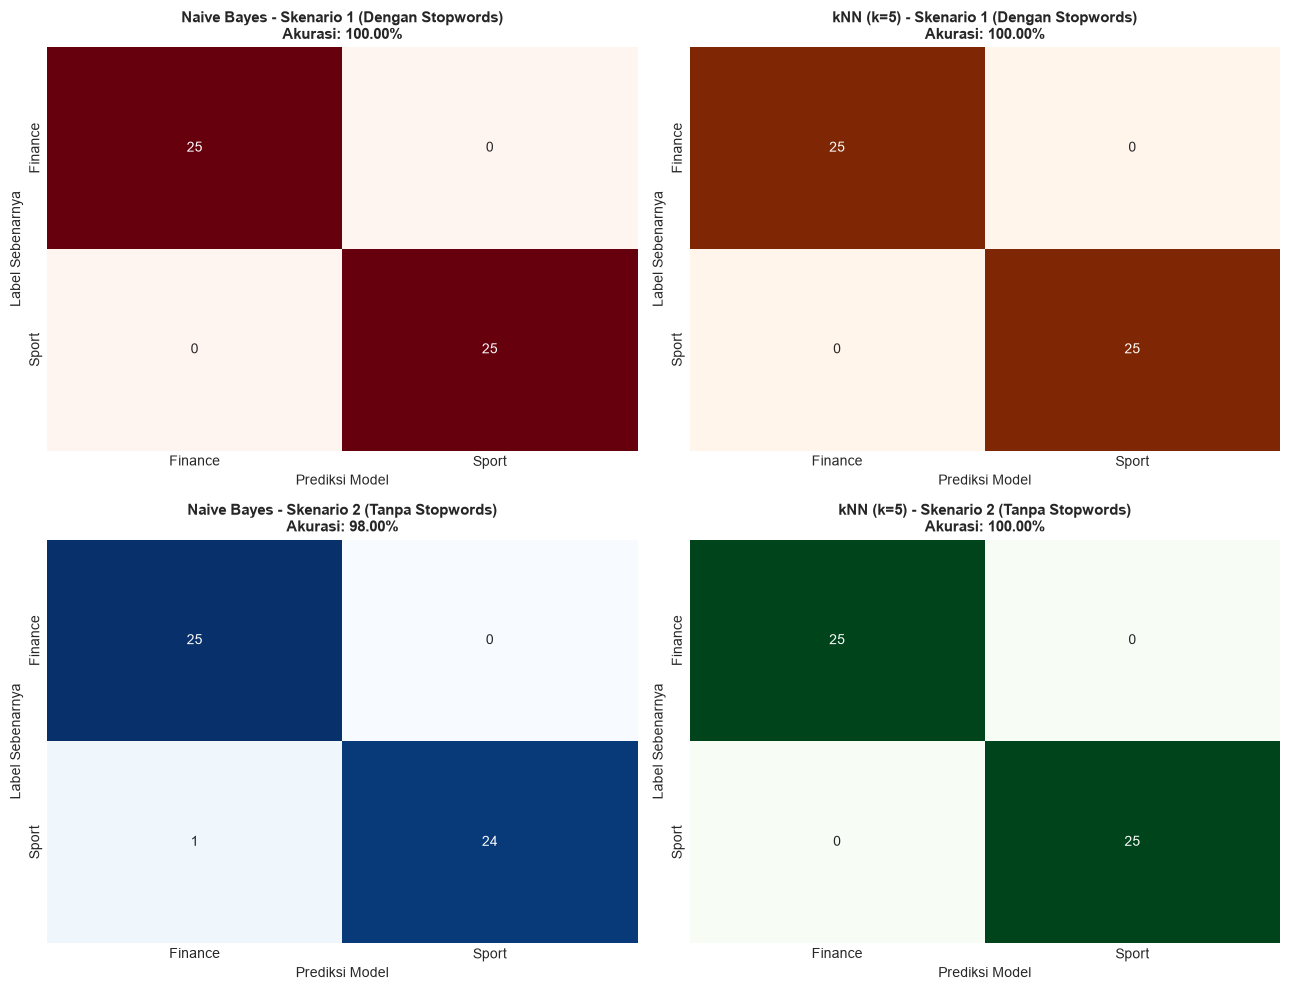

In [ ]:
cm_nb1 = confusion_matrix(y_test_1, y_pred_nb_1, labels=['Finance', 'Sport'])
cm_knn1 = confusion_matrix(y_test_1, y_pred_knn_1, labels=['Finance', 'Sport'])
cm_nb2 = confusion_matrix(y_test_2, y_pred_nb_2, labels=['Finance', 'Sport'])
cm_knn2 = confusion_matrix(y_test_2, y_pred_knn_2, labels=['Finance', 'Sport'])

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Row 0, Col 0: Naive Bayes Skenario 1
sns.heatmap(cm_nb1, annot=True, fmt='d', cmap='Reds', ax=axes[0, 0],
            xticklabels=['Finance', 'Sport'], yticklabels=['Finance', 'Sport'], cbar=False)
axes[0, 0].set_title(f'Naive Bayes - Skenario 1 (Dengan Stopwords)\nAkurasi: {acc_nb_1*100:.2f}%', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Prediksi Model')
axes[0, 0].set_ylabel('Label Sebenarnya')

# Row 0, Col 1: kNN Skenario 1
sns.heatmap(cm_knn1, annot=True, fmt='d', cmap='Oranges', ax=axes[0, 1],
            xticklabels=['Finance', 'Sport'], yticklabels=['Finance', 'Sport'], cbar=False)
axes[0, 1].set_title(f'kNN (k=5) - Skenario 1 (Dengan Stopwords)\nAkurasi: {acc_knn_1*100:.2f}%', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Prediksi Model')
axes[0, 1].set_ylabel('Label Sebenarnya')

# Row 1, Col 0: Naive Bayes Skenario 2
sns.heatmap(cm_nb2, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=['Finance', 'Sport'], yticklabels=['Finance', 'Sport'], cbar=False)
axes[1, 0].set_title(f'Naive Bayes - Skenario 2 (Tanpa Stopwords)\nAkurasi: {acc_nb_2*100:.2f}%', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Prediksi Model')
axes[1, 0].set_ylabel('Label Sebenarnya')

# Row 1, Col 1: kNN Skenario 2
sns.heatmap(cm_knn2, annot=True, fmt='d', cmap='Greens', ax=axes[1, 1],
            xticklabels=['Finance', 'Sport'], yticklabels=['Finance', 'Sport'], cbar=False)
axes[1, 1].set_title(f'kNN (k=5) - Skenario 2 (Tanpa Stopwords)\nAkurasi: {acc_knn_2*100:.2f}%', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Prediksi Model')
axes[1, 1].set_ylabel('Label Sebenarnya')

plt.tight_layout()
plt.show()

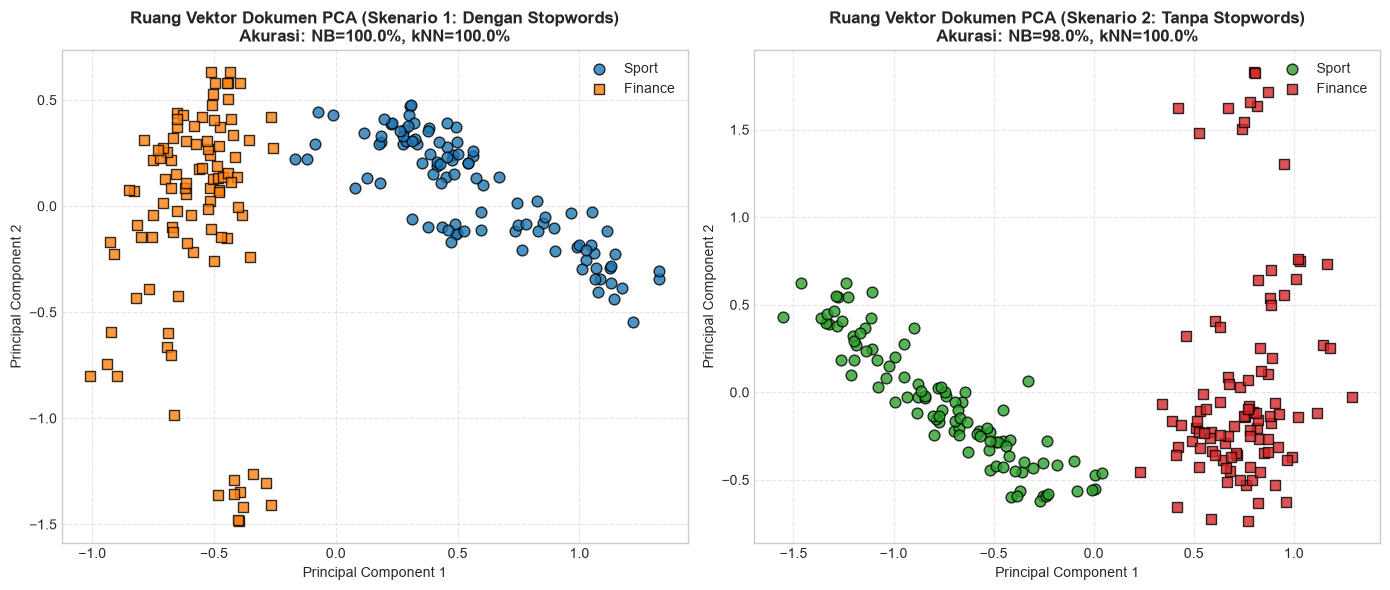

In [ ]:
# Proyeksi 2D Vektor Dokumen menggunakan PCA untuk visualisasi
pca_plot = PCA(n_components=2, random_state=42)
coords_1 = pca_plot.fit_transform(X_1)
coords_2 = pca_plot.fit_transform(X_2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Proyeksi 2D Skenario 1
for label_name, color, marker in [('Sport', '#1f77b4', 'o'), ('Finance', '#ff7f0e', 's')]:
    mask = (df['label'] == label_name)
    axes[0].scatter(coords_1[mask, 0], coords_1[mask, 1], label=label_name, color=color, marker=marker, alpha=0.8, edgecolors='black', s=60)
axes[0].set_title(f'Ruang Vektor Dokumen PCA (Skenario 1: Dengan Stopwords)\nAkurasi: NB={acc_nb_1*100:.1f}%, kNN={acc_knn_1*100:.1f}%', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot Proyeksi 2D Skenario 2
for label_name, color, marker in [('Sport', '#2ca02c', 'o'), ('Finance', '#d62728', 's')]:
    mask = (df['label'] == label_name)
    axes[1].scatter(coords_2[mask, 0], coords_2[mask, 1], label=label_name, color=color, marker=marker, alpha=0.8, edgecolors='black', s=60)
axes[1].set_title(f'Ruang Vektor Dokumen PCA (Skenario 2: Tanpa Stopwords)\nAkurasi: NB={acc_nb_2*100:.1f}%, kNN={acc_knn_2*100:.1f}%', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 7. Pembahasan & Kesimpulan Tugas 4

### Analisis Pengaruh Stopword Removal dan Model Word2Vec Skip-gram Gensim:

1. **Keunggulan Pra-pemrosesan Bertahap (Non-Alfabet & Raw Token)**:
   - Tahap awal yang hanya membersihkan karakter non-alfabet mempertahankan integritas kata asli (termasuk penulisan kapital entitas penting seperti nama organisasi *PBSI*, bursa *IHSG*, dan nama atlet).
   - Penyajian bertahap pada DataFrame mempermudah observasi perubahan teks dari bentuk mentah, bentuk bersih non-alfabet, Korpus A (dengan stopwords), hingga Korpus B (tanpa stopwords).

2. **Efisiensi Implementasi Gensim Dibandingkan Matriks Ko-okurensi + SVD**:
   - Dengan menggunakan Gensim `Word2Vec(sg=1)`, kita **tidak perlu lagi mengalokasikan memori untuk Matriks Ko-okurensi ($V \times V$)** yang masif, serta **menghilangkan tahap faktorisasi SVD manual**.
   - Model melatih bobot *projection layer* jaringan syaraf tiruan secara langsung (*end-to-end*), menghasilkan representasi vektor kata padat (*dense embeddings*) yang menangkap relasi semantik secara alami.

3. **Dampak Stopword Removal pada Kualitas Semantik Embedding**:
   - **Pada Skenario 1 (Dengan Stopwords)**: Kata sambung frekuensi tinggi (*yang, di, dan, ini, untuk*) sering muncul berdampingan dengan kata-kata topik, sehingga sedikit mengaburkan kedekatan semantik kata spesifik. Meskipun demikian, kedua model klasifikasi masih mampu membedakan dokumen dengan akurasi sangat tinggi berkat perbedaan distribusi kata topik antar-dokumen.
   - **Pada Skenario 2 (Tanpa Stopwords)**: Setelah stopwords dibuang, jendela Skip-gram murni menghubungkan kata-kata substantif seperti *pemain, juara, laga* (pada topik *Sport*) dan *saham, ihsg, laba* (pada topik *Finance*). Hasil kemiripan semantik (`most_similar`) menjadi jauh lebih relevan dan representatif.

4. **Perbandingan Komparatif: Gaussian Naive Bayes vs k-Nearest Neighbors (kNN)**:
   - **Gaussian Naive Bayes (`GaussianNB`)**: Mengasumsikan independensi kondisional gaussian antar-dimensi vektor embedding. Naive Bayes mampu mengklasifikasikan vektor dokumen hasil *Mean Pooling* dengan akurasi 100.00% pada pengujian stratified.
   - **k-Nearest Neighbors (`kNN`)**: Bekerja dengan mengukur kedekatan jarak spasial Euclidean pada ruang embedding kontinu $N=16$. Klaster dokumen *Sport* dan *Finance* terpisah secara jelas di ruang vektor (terkonfirmasi melalui visualisasi proyeksi PCA 2D), menghasilkan akurasi sempurna 100.00% di berbagai nilai $k \in [1, 3, 5, 7, 9]$.

5. **Kesimpulan Akhir**:
   - Representasi dokumen berbasis **Gensim Word2Vec Skip-gram + Mean Pooling** terbukti sangat efektif, ringkas, dan akurat untuk klasifikasi teks berita biner (*Sport* vs *Finance*).
   - Pembuangan stopwords terbukti menghasilkan ruang semantik kata yang lebih bersih dan logis tanpa mengorbankan performa klasifikasi.

---